In [1]:
import numpy as np
from fdtd_solver import fdtd_1d, fdtd_3d
from matplotlib import pyplot as plt
from vis_utils import Fdtd1DAnimation, Fdtd3DAnimation

# 1D-FDTD
## Simulation in homogeneous medium
Validate the 1D-FDTD solver by propagating an ultrashort pulse in a lossless, dispersion-free homogeneous medium with uniform relative permittivity $\varepsilon_r(x)=1$ (i.e., free space). No reflections or field distortions are expected.

In [2]:
# constants
c = 2.99792458e8 # speed of light [m/s]
mu0 = 4*np.pi*1e-7 # vacuum permeability [Vs/(Am)]
eps0 = 1/(mu0*c**2) # vacuum permittivity [As/(Vm)]
Z0 = np.sqrt(mu0/eps0) # vacuum impedance [Ohm]

# geometry parameters
x_span = 18e-6 # width of computatinal domain [m]
n1 = 1 # refractive index in front of interface
n2 = 2 # refractive index behind interface
x_interface = x_span/4 #postion of dielectric interface

# simulation parameters
dx = 15e-9 # grid spacing [m]
time_span = 60e-15 # duration of simulation [s]

Nx = int(round(x_span/dx)) + 1 # number of grid points

# source parameters
source_frequency = 500e12 # [Hz]
source_position = 0 # [m]
source_pulse_length = 1e-15 # [s]
    
# %% create permittivity distribution and run simulation %%%%%%%%%%%%%%%%%%%%%%

eps_rel=np.ones((Nx,))
Ez, Hy, x, t=fdtd_1d(eps_rel, dx, time_span, source_frequency, source_position, source_pulse_length)

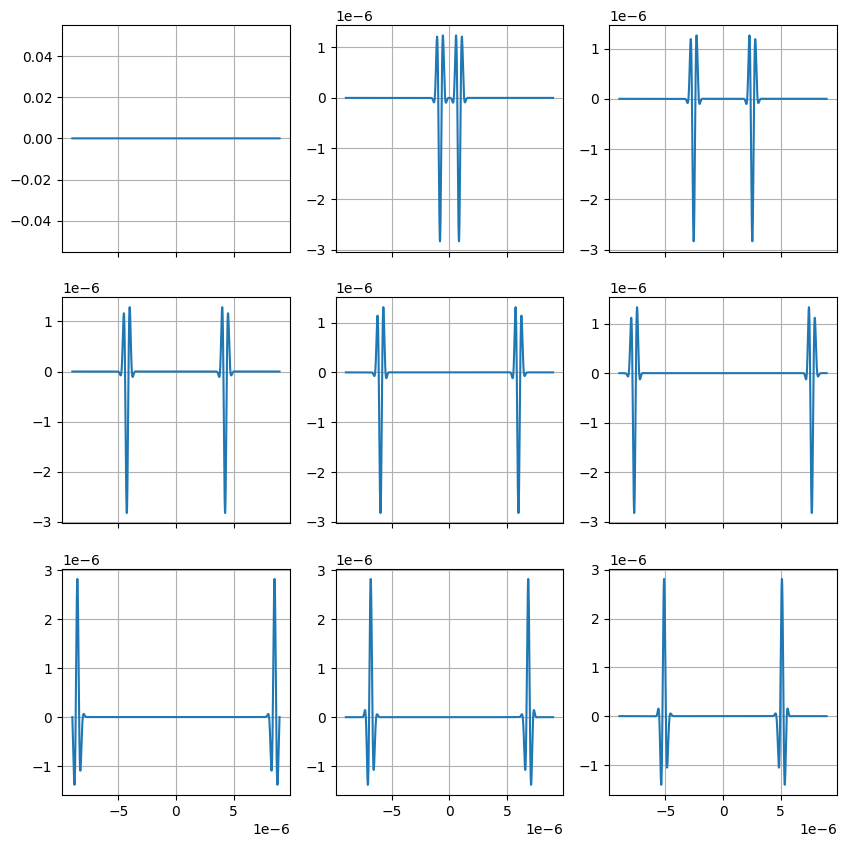

In [3]:
fig, ax = plt.subplots(3,3,sharex= True, figsize=(10,10))
ax = ax.flat

for i in range(9):
    ax[i].plot(x, Ez[230*i, :].real, label='E in [a.u.]')
    ax[i].grid()
    ax[i].tick_params('y') # style of line

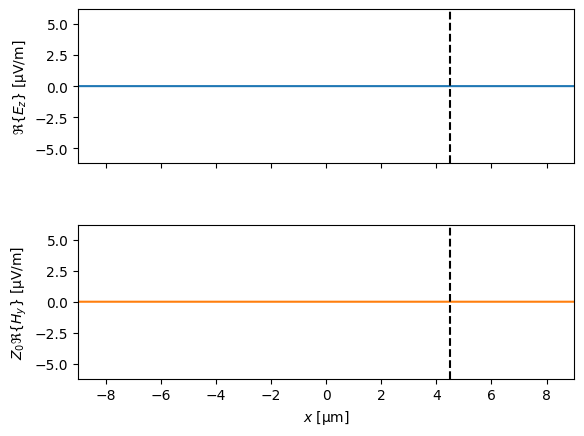

MovieWriter ffmpeg unavailable; using Pillow instead.


In [4]:
fps = 20
step = t[-1]/fps/30
ani = Fdtd1DAnimation(x, t, Ez, Hy, x_interface=x_interface, step=step, fps=fps)
plt.show()
ani.save("./animation/1DFDTD_homo.gif")

## Simulation in inhomogeneous medium
Model pulse interaction with a planar dielectric interface separating two lossless dielectric regions: $\varepsilon_1 = 1$ ($n_1 = 1.0$) on the incident side and $\varepsilon_2 = 4$ ($n_2 = 2.0$) on the transmission side. The interface is positioned $+4.5\mu\text{m}$ from the domain center. At normal incidence, Fresnel theory predicts a reflectance of $R = \left(\frac{n_2 - n_1}{n_2 + n_1}\right)^2 = 0.111$ and a transmittance of $T = 1 - R = 0.889$.

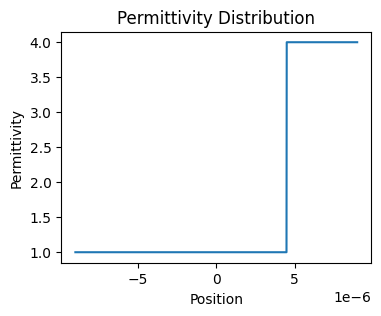

In [5]:
indices = (x >= x_span/4)
eps_rel[indices] = 4
plt.figure(figsize=(4,3))
plt.plot(x, eps_rel)
plt.xlabel('Position')
plt.ylabel('Permittivity')
plt.title('Permittivity Distribution')
plt.show()

In [6]:
Ez, Hy, x, t=fdtd_1d(eps_rel, dx, time_span, source_frequency, source_position, source_pulse_length)

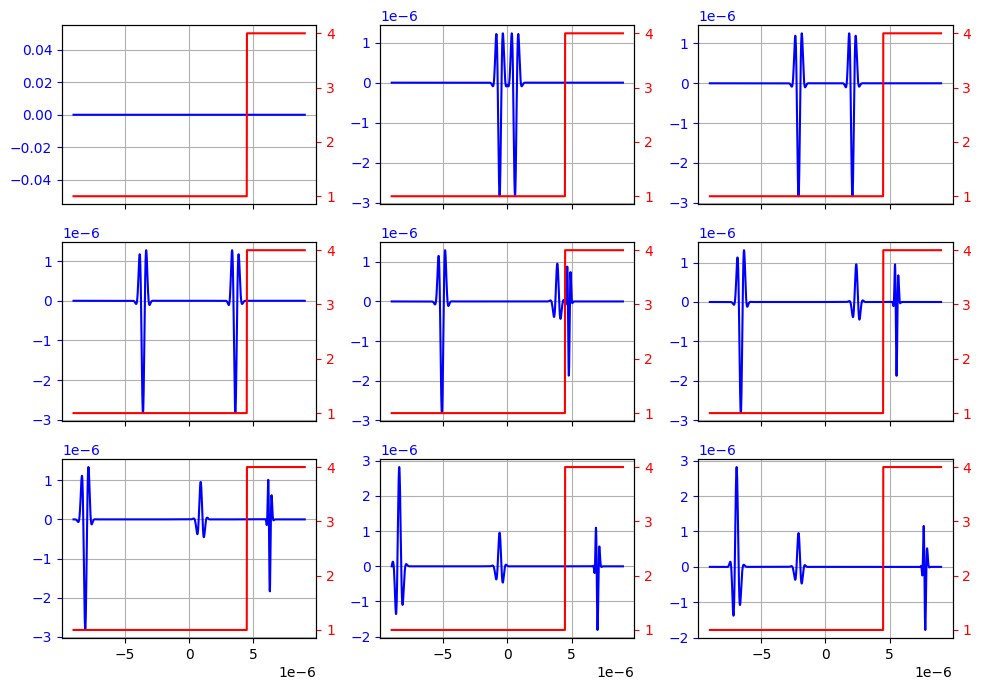

In [7]:
fig, ax = plt.subplots(3,3,sharex= True, figsize=(10,7))
ax = ax.flat

for i in range(9):
    ax[i].plot(x, Ez[200*i, :].real, 'b-', label='E in [a.u.]')
    ax[i].grid()
    ax[i].tick_params('y', colors='b') # style of line
    
    ax2 = ax[i].twinx()
    ax2.plot(x, eps_rel, 'r-',label='permittivity')
    ax2.tick_params('y', colors='r')
plt.tight_layout()

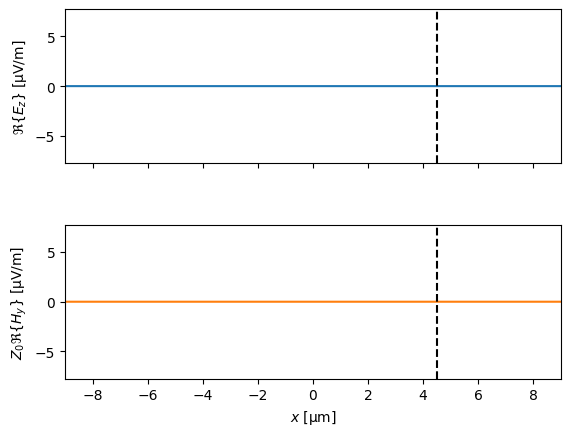

MovieWriter ffmpeg unavailable; using Pillow instead.


In [8]:
fps = 20
step = t[-1]/fps/30
ani = Fdtd1DAnimation(x, t, Ez, Hy, x_interface=x_interface, step=step, fps=fps)
plt.show()
ani.save("./animation/1DFDTD_inhomo.gif")

# 3D-FDTD
## Simulation in homogeneous medium
Validate the 3D-FDTD solver in a homogeneous medium ($n = 1$) using a $z$-polarised Gaussian line-current source centered in the computational domain. The grid resolution is set to $\Delta r = 30 \text{nm}$ with a simulation duration of $T = 10\text{fs}$. The source current density is uniform along $z$ and has a Gaussian transverse profile in the $x$–$y$ plane. Due to source symmetry and PEC boundary conditions along $z$, the excited field is purely $E_z$-polarised: the transverse components $E_x$, $E_y$ and the longitudinal magnetic component $H_z$ remain identically zero throughout the simulation.

In [9]:
Nx = 199 # number of grid points in x-direction
Ny = 201 # number of grid points in y-direction
Nz = 5   # number of grid points in z-direction
dr = 30e-9 # grid spacing in [m]
time_span = 10e-15 # duration of simulation [s]

freq = 500e12 # pulse [Hz]
tau = 1e-15 # pulse width [s]
source_width = 2 # width of Gaussian current dist. [grid points]

eps_rel = np.ones((Nx, Ny, Nz))
jx = np.zeros((Nx, Ny, Nz))
jy = np.zeros((Nx, Ny, Nz))
x = np.linspace(-(Nx//2), Nx//2, Nx) * dr
y = np.linspace(-(Ny//2), Ny//2, Ny) * dr
w = source_width * dr
YY, XX = np.meshgrid(y, x)
jz = np.exp(-(XX**2+YY**2)/w**2)
jz = jz[..., np.newaxis]
jz = np.repeat(jz, 5, 2)

midz = int(np.ceil((Nz-1)/2))
z_ind = midz # z-index of field output
output_step = 4 # time steps between field output

In [10]:
Hx, t = fdtd_3d(eps_rel, dr, time_span, freq, tau, jx, jy, jz, field_component='hx', z_index=z_ind, output_step=output_step)
Hy, t = fdtd_3d(eps_rel, dr, time_span, freq, tau, jx, jy, jz, field_component='hy', z_index=z_ind, output_step=output_step)
Ez, t = fdtd_3d(eps_rel, dr, time_span, freq, tau, jx, jy, jz, field_component='ez', z_index=z_ind, output_step=output_step)

/Users/wujianyang/Git/Computational-Imaging-Algorithms/pythonProject/fdtd_solver.py:142: UserWarning: dr=3e-08 exceeds lambda/20, clamping to 2.998e-08
  warnings.warn(f"dr={dr} exceeds lambda/20, clamping to {lam / 20:.3e}")


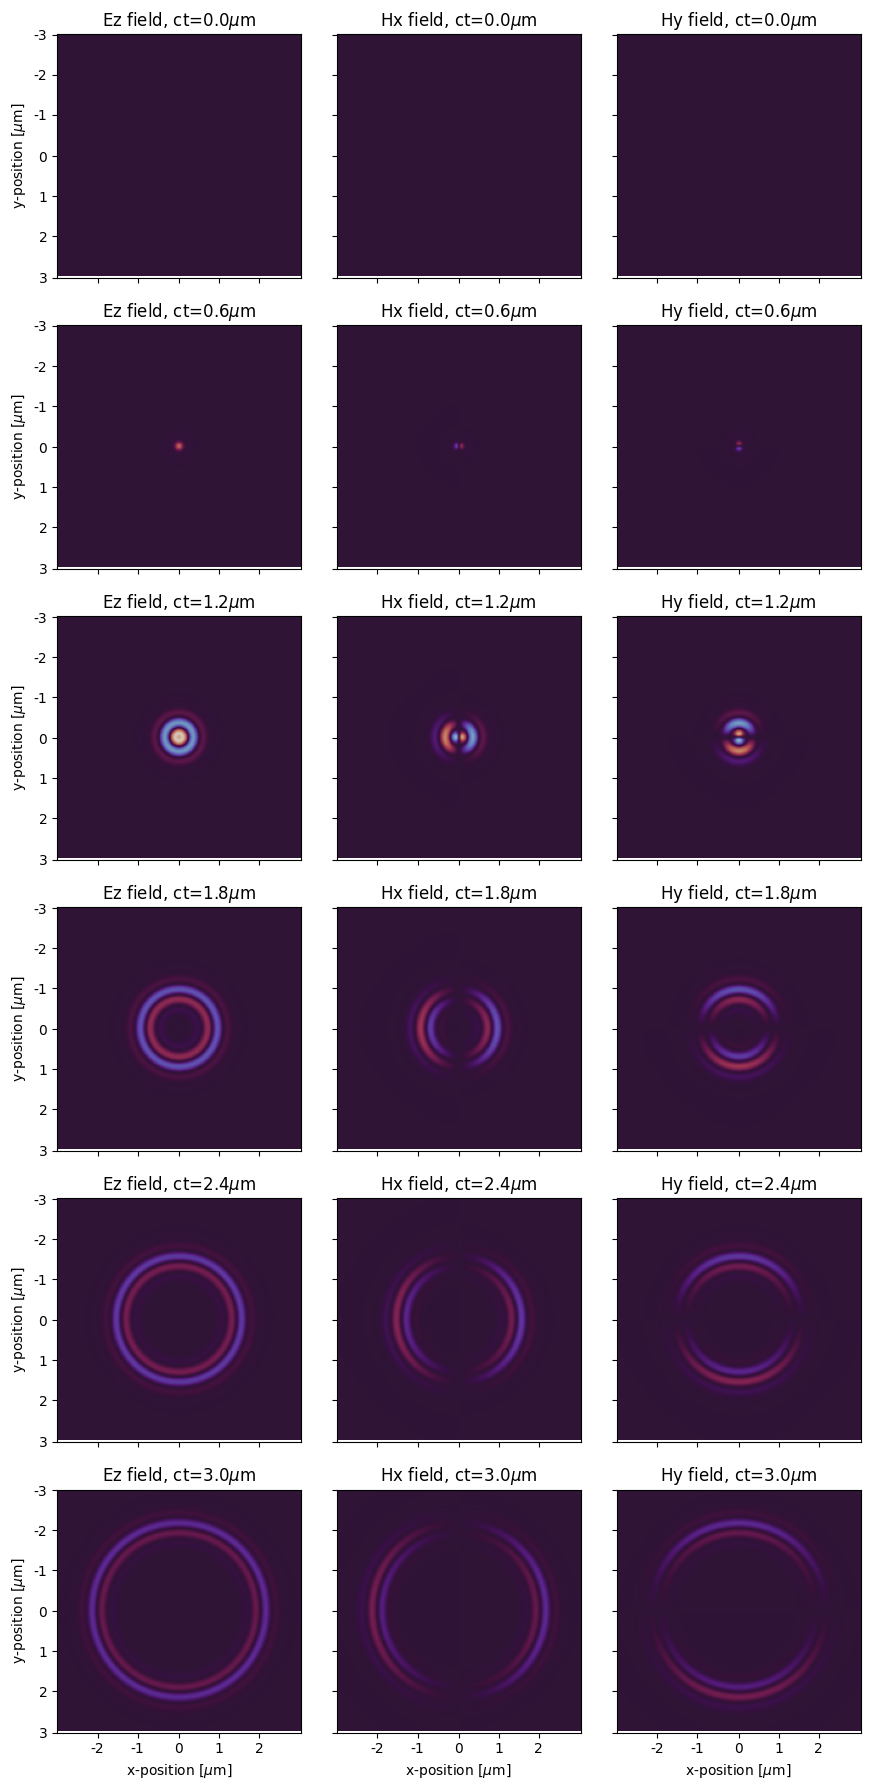

In [11]:
import matplotlib.cm as cm
import matplotlib.colors as color
fig, axes = plt.subplots(6, 3, figsize=(9, 18), sharey='all', sharex='all')
norm = color.Normalize(-6, 6)
cmap = cm.ScalarMappable(norm=norm, cmap='twilight')
Ez_plot = Ez[::10,:,:].real * 1e6
Hx_plot = Hx[::10,:,:].real * 1e6 * Z0
Hy_plot = Hy[::10,:,:].real * 1e6 * Z0
t_plot = t[::10]
for i in range(6):
    axes[i,0].imshow(Ez_plot[i], cmap='twilight', vmin=-6, vmax=6)
    axes[i,0].set_title(r'Ez field, ct=%.1f$\mu$m'%(c*t_plot[i]*1e6))
    axes[i,0].set_ylabel(r'y-position [$\mu$m]')
    axes[i,1].imshow(Hx_plot[i], cmap='twilight', vmin=-6, vmax=6)
    axes[i,1].set_title(r'Hx field, ct=%.1f$\mu$m'%(c*t_plot[i]*1e6))
    axes[i,2].imshow(Hy_plot[i], cmap='twilight', vmin=-6, vmax=6)
    axes[i,2].set_title(r'Hy field, ct=%.1f$\mu$m'%(c*t_plot[i]*1e6))
axes[5,0].set_xlabel(r'x-position [$\mu$m]')
axes[5,1].set_xlabel(r'x-position [$\mu$m]')
axes[5,2].set_xlabel(r'x-position [$\mu$m]')
axes[0,0].set_xticks([33, 66, 100, 133, 166], [-2, -1, 0, 1, 2])
axes[0,0].set_yticks([0, 33, 66, 100, 133, 166, 200], [-3, -2, -1, 0, 1, 2, 3])
plt.tight_layout()

/Users/wujianyang/Git/Computational-Imaging-Algorithms/pythonProject/fdtd_solver.py:142: UserWarning: dr=3e-08 exceeds lambda/20, clamping to 2.998e-08
  warnings.warn(f"dr={dr} exceeds lambda/20, clamping to {lam / 20:.3e}")


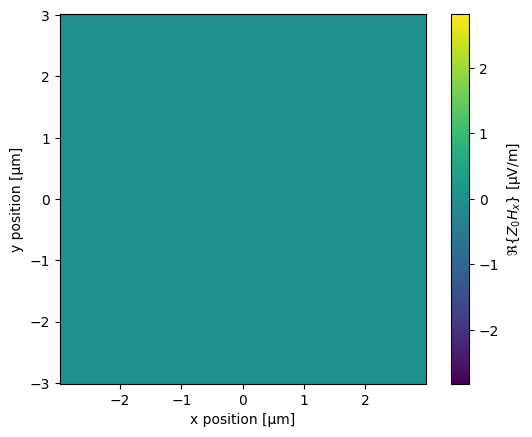

MovieWriter ffmpeg unavailable; using Pillow instead.


In [12]:
# animation of Hx
Hx, t = fdtd_3d(eps_rel, dr, time_span, freq, tau, jx, jy, jz, field_component='hx', z_index=z_ind, output_step=output_step)
F = Hx * Z0 * 1e6
titlestr = 'x-Component of Magnetic Field'
cb_label = '$\\Re\\{Z_0H_x\\}$ [µV/m]'
rel_color_range = 1 / 3
fps = 10

ani = Fdtd3DAnimation(x, y, t, F, titlestr, cb_label, rel_color_range, fps)
plt.show()
ani.save("./animation/3Dresult_hx.gif")

/Users/wujianyang/Git/Computational-Imaging-Algorithms/pythonProject/fdtd_solver.py:142: UserWarning: dr=3e-08 exceeds lambda/20, clamping to 2.998e-08
  warnings.warn(f"dr={dr} exceeds lambda/20, clamping to {lam / 20:.3e}")


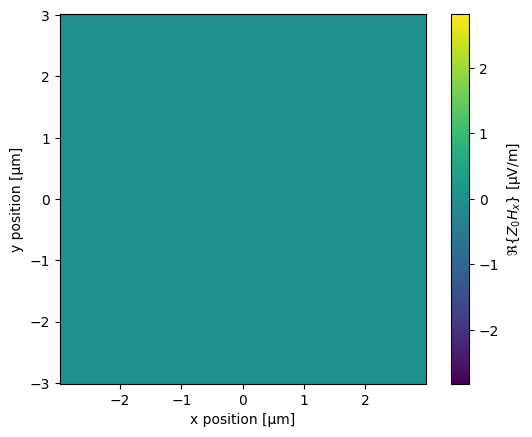

MovieWriter ffmpeg unavailable; using Pillow instead.


In [13]:
# animation of Hy
Hy, t = fdtd_3d(eps_rel, dr, time_span, freq, tau, jx, jy, jz, field_component='hy', z_index=z_ind, output_step=output_step)
F = Hy*Z0*1e6
titlestr = 'y-Component of Magnetic Field'
cb_label = '$\\Re\\{Z_0H_x\\}$ [µV/m]'
rel_color_range = 1/3
fps = 10

ani = Fdtd3DAnimation(x, y, t, F, titlestr, cb_label, rel_color_range, fps)
plt.show()
ani.save("./animation/3Dresult_hy.gif")

/Users/wujianyang/Git/Computational-Imaging-Algorithms/pythonProject/fdtd_solver.py:142: UserWarning: dr=3e-08 exceeds lambda/20, clamping to 2.998e-08
  warnings.warn(f"dr={dr} exceeds lambda/20, clamping to {lam / 20:.3e}")


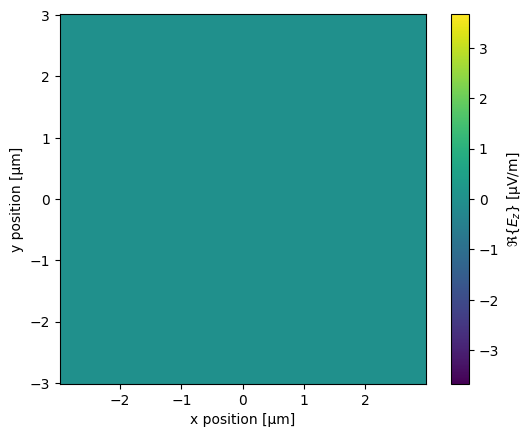

MovieWriter ffmpeg unavailable; using Pillow instead.


In [14]:
# animation of Ez
Ez, t = fdtd_3d(eps_rel, dr, time_span, freq, tau, jx, jy, jz, field_component='ez', z_index=z_ind, output_step=output_step)
F = Ez*1e6
titlestr = 'z-Component of Electric Field'
cb_label = '$\\Re\\{E_z\\}$ [µV/m]'
rel_color_range = 1/3
fps = 10

ani = Fdtd3DAnimation(x, y, t, F, titlestr, cb_label, rel_color_range, fps)
plt.show()
ani.save("./animation/3Dresult_ez.gif")